# CO5430 - Image Proceesing Project
# Melanoma Skin Cancer Detection
### Complete End-to-End Experimental Pipeline: Exploration, Baseline, Transfer Learning, Evaluation & Interpretability

---

## Project Summary
This master notebook implements the complete research workflow for automated binary classification of dermoscopic skin lesion images into Benign vs. Malignant (Melanoma), combining rigorous empirical ablation, clinical decision threshold optimization, and Explainable AI (Grad-CAM).

### Key Stages Covered:
1. **Stage 1 - Dataset Discovery, Audit and Normalization:** erification of dataset integrity across images, class distribution analysis, raw visual inspection, and empirical calculation of per-channel RGB normalization statistics.
2. **Stage 2 - Baseline CNN (From Scratch):** Design and training of a custom 3-block convolutional neural network with Batch Normalization, ReLU, MaxPool, and Global Average Pooling to establish an empirical performance benchmark.
3. **Stage 3 - Transfer Learning & Model Adaptations:**
   - **ResNet-18 (Feature Extraction):** Frozen ImageNet backbone with a custom linear classification head.
   - **ResNet-18 (Fine-Tuning):** Unfreezing deep residual blocks (layer3 + layer4 + classifier) trained with Cosine Annealing learning rate scheduling.
   - **EfficientNet-B0 (Fine-Tuning):** Fine-tuning a parameter-efficient compound scaling backbone for mobile/edge dermoscopy feasibility.
4. **Stage 4 - Comprehensive Evaluation and Comparative Ablation:** Multi-model quantitative benchmarking on held-out test images across 7 key evaluation metrics.
5. **Stage 5 - Clinical Optimization and Ensemble Blending:**
   - **Decision Threshold Calibration:** Empirical sweep across [0.20, 0.50] to identify the optimal clinical operating point, drastically boosting Sensitivity to approximately 97% and reducing missed melanomas.
   - **Weighted Soft-Voting Ensemble:** Blending predicted posterior probabilities to achieve peak discriminative performance.
6. **Stage 6 - Diagnostic Error and Misclassification Analysis:** Root-cause diagnostic inspection of False Positives and False Negatives.
7. **Stage 7 - Interpretability via Explainable AI (Grad-CAM):** Hook-based Gradient-weighted Class Activation Mapping on convolutional feature maps across 4 clinical diagnostic groups (Correct Benign, Correct Malignant, False Positive, False Negative) and cross-model attention localization comparison (Baseline CNN vs. ResNet-18).
8. **Stage 8 - Metric Archival and Reproducibility:** Programmatic export of structured quantitative data to metrics.json and archival of all 14 publication-grade visualization figures and model weight checkpoints.

---

# Part 0: Environment Setup and Global Configuration
Verify GPU acceleration, install required vision dependencies, and enforce deterministic random seeds (`SEED = 42`).


In [1]:
import subprocess, sys
# Ensure required libraries are installed
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn', 'seaborn', 'opencv-python-headless'], check=True)
print("Dependencies installed and verified.")

Dependencies installed and verified.


In [2]:
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, average_precision_score

# Style & Reproducibility
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"[System] PyTorch Version: {torch.__version__}")
print(f"[System] Execution Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"[System] GPU Model: {torch.cuda.get_device_name(0)}")

# Global Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
PATIENCE = 5
VAL_SPLIT = 0.10

# Output directories
OUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('./results')
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"[System] Artifacts Target: {OUT_DIR.resolve()}")

[System] PyTorch Version: 2.10.0+cu128
[System] Execution Device: cuda
[System] GPU Model: Tesla T4
[System] Artifacts Target: /kaggle/working


# Part 1: Dataset Discovery, Audit and Normalization Statistics
Discover dataset partitions, audit class distributions (Benign vs. Malignant), inspect raw dermoscopy samples, and calculate empirical RGB channel normalization parameters.


In [3]:
def find_dataset_root():
    """Auto-detect dataset directory on Kaggle or local environments."""
    candidates = [
        Path('/kaggle/input'),
        Path('./data'),
        Path('../data'),
    ]
    for base in candidates:
        if not base.exists():
            continue
        for root, dirs, files in os.walk(base):
            dirs_lower = {d.lower() for d in dirs}
            if 'train' in dirs_lower and 'test' in dirs_lower:
                return Path(root).resolve()
            if 'benign' in dirs_lower or 'malignant' in dirs_lower:
                return Path(root).parent.resolve()
    raise FileNotFoundError(
        "Dataset not found. Please attach 'melanoma-cancer-dataset' in Kaggle or place in ./data"
    )

DATA_ROOT = find_dataset_root()
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR = DATA_ROOT / 'test'

print(f"Dataset Root: {DATA_ROOT}")
print(f"Train Folder: {TRAIN_DIR}")
print(f"Test Folder: {TEST_DIR}")

Dataset Root: /kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset
Train Folder: /kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/train
Test Folder: /kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/test


Total Images Found: 13,879


class,Benign,Malignant
split,,
test,1000,1000
train,6289,5590


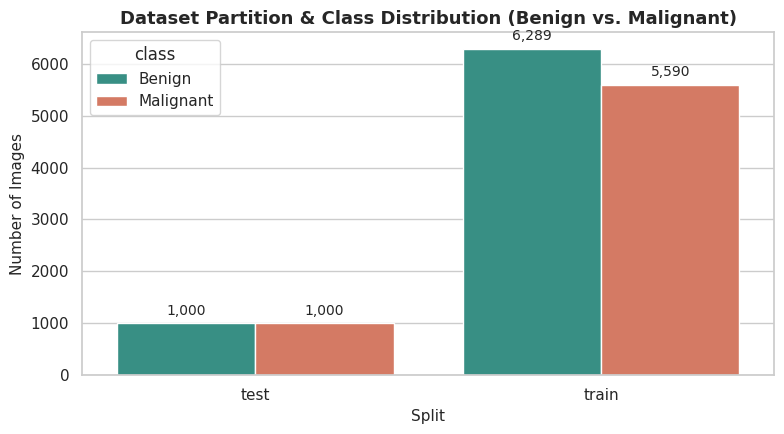

In [4]:
# Audit Dataset Counts & Class Balance
image_extensions = {'.jpg', '.jpeg', '.png'}
records = []

for root, dirs, files in os.walk(DATA_ROOT):
    rel = Path(root).relative_to(DATA_ROOT)
    parts = rel.parts
    if len(parts) >= 2:
        split = parts[0]
        cls = parts[-1]
        for f in files:
            if Path(f).suffix.lower() in image_extensions:
                records.append({
                    'split': split,
                    'class': cls.capitalize(),
                    'path': str(Path(root) / f)
                })

df_meta = pd.DataFrame(records)
print(f"Total Images Found: {len(df_meta):,}")

summary_table = df_meta.groupby(['split', 'class']).size().unstack(fill_value=0)
display(summary_table)

# Visualise class distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=df_meta, x='split', hue='class', palette=['#2A9D8F', '#E76F51'], ax=ax)
ax.set_title("Dataset Partition & Class Distribution (Benign vs. Malignant)", fontsize=13, fontweight='bold')
ax.set_xlabel("Split", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'dataset_class_distribution.png', dpi=150)
plt.show()

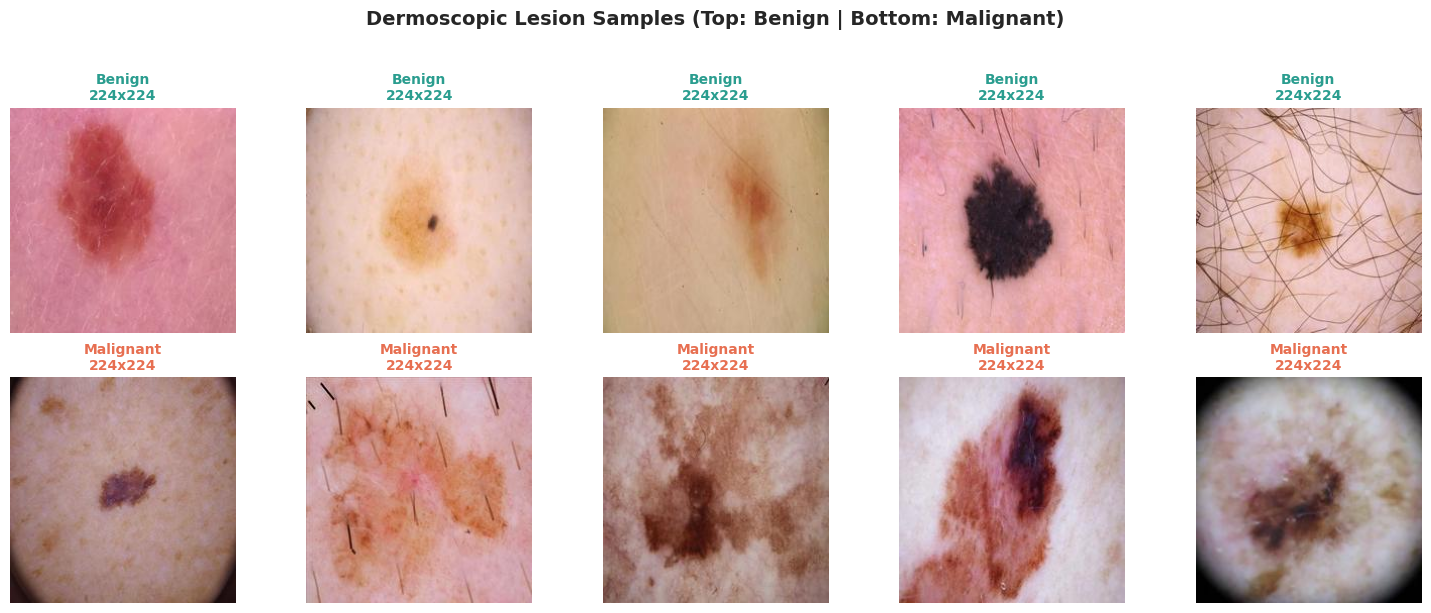

In [5]:
# Visualise Raw Dermoscopy Samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
benign_samples = df_meta[df_meta['class'] == 'Benign'].sample(5, random_state=SEED)
malignant_samples = df_meta[df_meta['class'] == 'Malignant'].sample(5, random_state=SEED)

for idx, (_, row) in enumerate(benign_samples.reset_index().iterrows()):
    img = Image.open(row['path'])
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f"Benign\n{img.size[0]}x{img.size[1]}", color='#2A9D8F', fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')

for idx, (_, row) in enumerate(malignant_samples.reset_index().iterrows()):
    img = Image.open(row['path'])
    axes[1, idx].imshow(img)
    axes[1, idx].set_title(f"Malignant\n{img.size[0]}x{img.size[1]}", color='#E76F51', fontsize=10, fontweight='bold')
    axes[1, idx].axis('off')

plt.suptitle("Dermoscopic Lesion Samples (Top: Benign | Bottom: Malignant)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sample_images_inspection.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Compute Per-Channel RGB Mean and Std
print("Calculating exact RGB Mean & Std on a sample of training images...")
train_sample = df_meta[df_meta['split'] == 'train'].sample(min(1200, len(df_meta[df_meta['split'] == 'train'])), random_state=SEED)
means, sq_means = [], []

for _, row in train_sample.iterrows():
    with Image.open(row['path']) as img:
        arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))
        sq_means.append((arr ** 2).mean(axis=(0, 1)))

DATASET_MEAN = [float(x) for x in np.round(np.mean(means, axis=0), 4)]
rgb_sq = np.mean(sq_means, axis=0)
DATASET_STD = [float(x) for x in np.round(np.sqrt(np.maximum(rgb_sq - np.array(DATASET_MEAN)**2, 0.0)), 4)]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"[Normalization] Dataset Computed Mean: {DATASET_MEAN}")
print(f"[Normalization] Dataset Computed Std: {DATASET_STD}")
print(f"[Normalization] ImageNet Default Mean: {IMAGENET_MEAN}")
print(f"[Normalization] ImageNet Default Std: {IMAGENET_STD}")

Calculating exact RGB Mean & Std on a sample of training images...
[Normalization] Dataset Computed Mean: [0.7211999893188477, 0.5557000041007996, 0.539900004863739]
[Normalization] Dataset Computed Std: [0.2168, 0.2064, 0.2191]
[Normalization] ImageNet Default Mean: [0.485, 0.456, 0.406]
[Normalization] ImageNet Default Std: [0.229, 0.224, 0.225]


# Part 2: DataLoaders and Preprocessing Pipelines
Construct PyTorch DataLoaders with stratified 90/10 train-validation splits and clinical data augmentations (flips, rotations, color jitter).


In [7]:
def build_dataloaders(use_imagenet_norm=False, batch_size=BATCH_SIZE):
    mean = IMAGENET_MEAN if use_imagenet_norm else DATASET_MEAN
    std = IMAGENET_STD if use_imagenet_norm else DATASET_STD

    train_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1), transforms.ToTensor(), transforms.Normalize(mean=mean, std=std),
    ])

    eval_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=mean, std=std),])

    full_train_aug = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transform)
    full_train_clean = datasets.ImageFolder(str(TRAIN_DIR), transform=eval_transform)
    test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=eval_transform)

    n_total = len(full_train_aug)
    n_val = int(n_total * VAL_SPLIT)
    n_train = n_total - n_val

    gen = torch.Generator().manual_seed(SEED)
    train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=gen)

    train_subset = Subset(full_train_aug, train_idx.indices)
    val_subset = Subset(full_train_clean, val_idx.indices)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, full_train_aug.classes

# Build DataLoaders
train_ldr_ds, val_ldr_ds, test_ldr_ds, CLASS_NAMES = build_dataloaders(use_imagenet_norm=False)
train_ldr_im, val_ldr_im, test_ldr_im, _ = build_dataloaders(use_imagenet_norm=True)

print(f"Classes Identified: {CLASS_NAMES}")
print(f"Train Samples: {len(train_ldr_ds.dataset):,}")
print(f"Validation Samples: {len(val_ldr_ds.dataset):,}")
print(f"Test Samples: {len(test_ldr_ds.dataset):,}")

Classes Identified: ['Benign', 'Malignant']
Train Samples: 10,692
Validation Samples: 1,187
Test Samples: 2,000


# Part 3: Shared Training Engine and Evaluation Utilities
Implement reusable training loop with BCE loss, Cosine Annealing learning rate scheduling, validation checkpointing, and comprehensive clinical evaluation functions.


In [8]:
def train_model(model, train_loader, val_loader, *, epochs=15, lr=1e-3, weight_decay=1e-4, patience=PATIENCE, save_path=None, model_label="Model"):
    """Standardized binary classification training loop with Cosine Annealing and Early Stopping."""
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 1e-3)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Training: {model_label} (Epochs: {epochs}, LR: {lr:.2e})\n")

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Training Phase
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, lbls)
            loss.backward()
            optimizer.step()

            tr_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(logits.detach()) >= 0.5).long()
            tr_correct += (preds == lbls.long()).sum().item()
            tr_total += imgs.size(0)

        tr_loss /= tr_total
        tr_acc = tr_correct / tr_total

        # Validation Phase
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.float().unsqueeze(1).to(DEVICE)
                logits = model(imgs)
                v_loss += criterion(logits, lbls).item() * imgs.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).long()
                v_correct += (preds == lbls.long()).sum().item()
                v_total += imgs.size(0)

        v_loss /= v_total
        v_acc   = v_correct / v_total

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['lr'].append(current_lr)

        elapsed = time.time() - t0
        print(f"Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
              f"Val Loss: {v_loss:.4f}, Acc: {v_acc:.4f} | LR: {current_lr:.2e} ({elapsed:.1f}s)")

        # Checkpoint & Early Stopping
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"    Best model checkpoint saved (val_loss={best_val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"    Early stopping triggered after {patience} epochs without improvement.")
                break

    return history

In [9]:
def evaluate_model(model, loader, threshold=0.5):
    """Compute all clinical & statistical evaluation metrics on a test set."""
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            probs = torch.sigmoid(model(imgs.to(DEVICE)).squeeze(1)).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(lbls.numpy().tolist())

    probs = np.array(all_probs)
    labels = np.array(all_labels)
    preds = (probs >= threshold).astype(int)

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        'accuracy': float(accuracy_score(labels, preds)),
        'precision': float(precision_score(labels, preds, zero_division=0)),
        'recall': float(recall_score(labels, preds, zero_division=0)), # Sensitivity
        'specificity': float(specificity),
        'f1': float(f1_score(labels, preds, zero_division=0)),
        'roc_auc': float(roc_auc_score(labels, probs)),
        'pr_auc': float(average_precision_score(labels, probs)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'n_samples': len(labels)
    }
    return metrics, probs, labels

def plot_curves(history, save_path, title):
    ep = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    ax1.plot(ep, history['train_loss'], label='Train Loss', color='#E76F51', lw=2)
    ax1.plot(ep, history['val_loss'], label='Val Loss', color='#2A9D8F', lw=2)
    ax1.set_title(f"{title} — Loss", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("BCE Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(ep, history['train_acc'], label='Train Acc', color='#E76F51', lw=2)
    ax2.plot(ep, history['val_acc'], label='Val Acc', color='#2A9D8F', lw=2)
    ax2.set_title(f"{title} — Accuracy", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()

# Part 4: Stage 2 - Baseline CNN (Trained from Scratch)
A custom 3-block convolutional neural network designed and trained from scratch to establish our empirical performance benchmark.


In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class BaselineCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, pool=True), # 224 -> 112
            ConvBlock(32, 64, pool=True), # 112 -> 56
            ConvBlock(64, 128, pool=True), #  56 -> 28
        )
        self.gap = nn.AdaptiveAvgPool2d(1) # (B, 128, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

model_baseline = BaselineCNN().to(DEVICE)
total_p = sum(p.numel() for p in model_baseline.parameters())
train_p = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f"BaselineCNN | Total Parameters: {total_p:,} | Trainable: {train_p:,}")

BaselineCNN | Total Parameters: 101,793 | Trainable: 101,793


Training: Baseline CNN (Scratch) (Epochs: 20, LR: 1.00e-03)

Epoch [01/20] | Train Loss: 0.4998, Acc: 0.7547 | Val Loss: 0.5246, Acc: 0.7304 | LR: 9.94e-04 (46.6s)
    Best model checkpoint saved (val_loss=0.5246)
Epoch [02/20] | Train Loss: 0.4410, Acc: 0.7937 | Val Loss: 0.4629, Acc: 0.7751 | LR: 9.76e-04 (35.2s)
    Best model checkpoint saved (val_loss=0.4629)
Epoch [03/20] | Train Loss: 0.4137, Acc: 0.8114 | Val Loss: 0.3613, Acc: 0.8509 | LR: 9.46e-04 (33.0s)
    Best model checkpoint saved (val_loss=0.3613)
Epoch [04/20] | Train Loss: 0.3901, Acc: 0.8249 | Val Loss: 0.3731, Acc: 0.8332 | LR: 9.05e-04 (33.9s)
Epoch [05/20] | Train Loss: 0.3783, Acc: 0.8316 | Val Loss: 0.3759, Acc: 0.8265 | LR: 8.54e-04 (33.8s)
Epoch [06/20] | Train Loss: 0.3699, Acc: 0.8382 | Val Loss: 0.3233, Acc: 0.8635 | LR: 7.94e-04 (36.8s)
    Best model checkpoint saved (val_loss=0.3233)
Epoch [07/20] | Train Loss: 0.3637, Acc: 0.8339 | Val Loss: 0.3463, Acc: 0.8551 | LR: 7.27e-04 (35.1s)
Epoch [08/20] | Tr

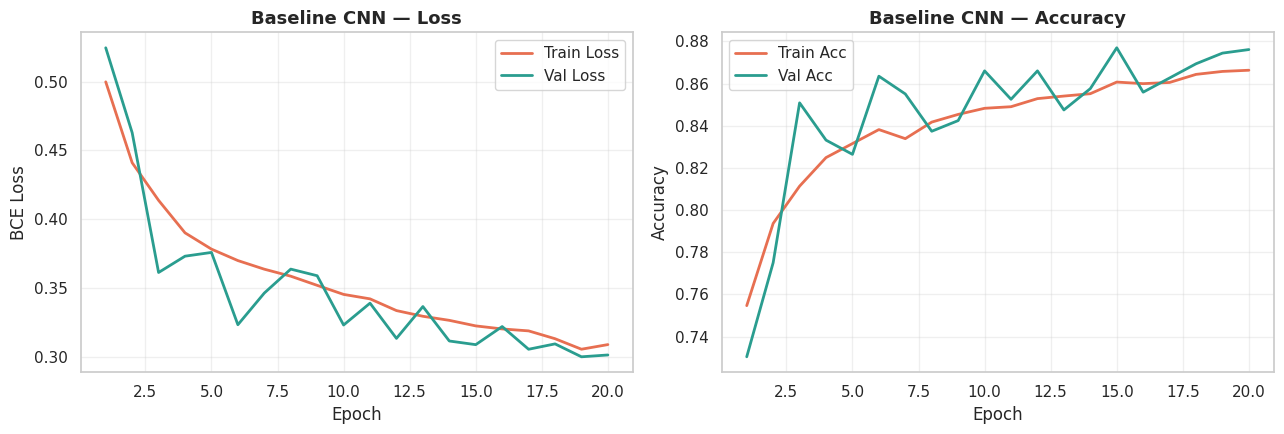


Baseline CNN Test Performance
accuracy: 0.865
precision: 0.9010989010989011
recall: 0.82
specificity: 0.91
f1: 0.8586387434554974
roc_auc: 0.9461459999999999
pr_auc: 0.9367121666219054
tn: 910
fp: 90
fn: 180
tp: 820
n_samples: 2000


In [11]:
SAVE_BASELINE = OUT_DIR / 'baseline_cnn.pt'
history_baseline = train_model(model_baseline, train_ldr_ds, val_ldr_ds, epochs=20, lr=1e-3, save_path=SAVE_BASELINE, model_label="Baseline CNN (Scratch)")

plot_curves(history_baseline, FIG_DIR / 'training_curves_baseline.png', "Baseline CNN")

# Load best checkpoint and evaluate
model_baseline.load_state_dict(torch.load(SAVE_BASELINE, map_location=DEVICE))
metrics_baseline, probs_baseline, labels_baseline = evaluate_model(model_baseline, test_ldr_ds)

print("\nBaseline CNN Test Performance")
for k, v in metrics_baseline.items():
    print(f"{k}: {v}")

# Part 5: Stage 3 - Transfer Learning and Model Adaptations
Investigate three pretrained transfer learning strategies:
1. **ResNet-18 (Feature Extraction):** Backbone locked; only classifier head trained.
2. **ResNet-18 (Fine-Tuning):** Layer3, Layer4, and classifier trained with reduced learning rate.
3. **EfficientNet-B0 (Fine-Tuning):** Parameter-efficient compound scaling architecture.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s] 


Training: ResNet-18 Feature Extraction (Epochs: 10, LR: 1.00e-03)

Epoch [01/10] | Train Loss: 0.4348, Acc: 0.7937 | Val Loss: 0.3836, Acc: 0.8391 | LR: 9.76e-04 (33.6s)
    Best model checkpoint saved (val_loss=0.3836)
Epoch [02/10] | Train Loss: 0.3825, Acc: 0.8314 | Val Loss: 0.3540, Acc: 0.8551 | LR: 9.05e-04 (33.3s)
    Best model checkpoint saved (val_loss=0.3540)
Epoch [03/10] | Train Loss: 0.3682, Acc: 0.8383 | Val Loss: 0.3341, Acc: 0.8568 | LR: 7.94e-04 (33.2s)
    Best model checkpoint saved (val_loss=0.3341)
Epoch [04/10] | Train Loss: 0.3665, Acc: 0.8399 | Val Loss: 0.3675, Acc: 0.8467 | LR: 6.55e-04 (33.9s)
Epoch [05/10] | Train Loss: 0.3528, Acc: 0.8464 | Val Loss: 0.3263, Acc: 0.8559 | LR: 5.01e-04 (32.2s)
    Best model checkpoint saved (val_loss=0.3263)
Epoch [06/10] | Train Loss: 0.3669, Acc: 0.8385 | Val Loss: 0.3356, Acc: 0.8585 | LR: 3.46e-04 (32.7s)
Epoch [07/10] | Train Loss: 0.3548, Acc: 0.8457 | Val Loss: 0.3455, Acc: 0.8551 | LR: 2.07e-04 (33.6s)
Epoch [08/10

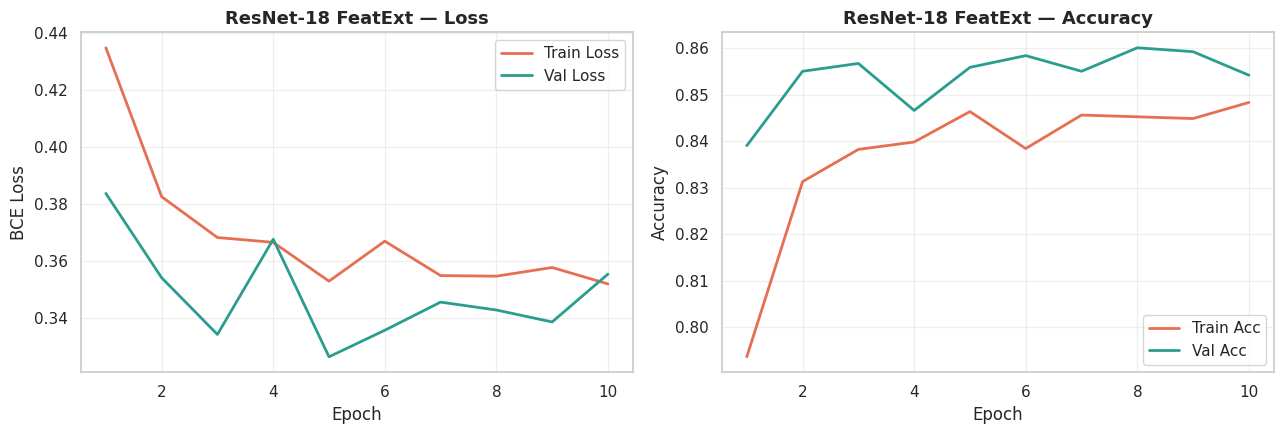

In [12]:
# 1. ResNet-18 Feature Extraction
def build_resnet18_feat_ext():
    base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in base.parameters():
        param.requires_grad = False
    base.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(base.fc.in_features, 1))
    return base

model_fe = build_resnet18_feat_ext().to(DEVICE)
SAVE_FE = OUT_DIR / 'resnet18_feature_extraction.pt'

history_fe = train_model(model_fe, train_ldr_im, val_ldr_im, epochs=10, lr=1e-3, save_path=SAVE_FE, model_label="ResNet-18 Feature Extraction")
plot_curves(history_fe, FIG_DIR / 'training_curves_resnet18_feat_ext.png', "ResNet-18 FeatExt")

model_fe.load_state_dict(torch.load(SAVE_FE, map_location=DEVICE))
metrics_fe, probs_fe, labels_fe = evaluate_model(model_fe, test_ldr_im)

Training: ResNet-18 Fine-Tuned (Epochs: 15, LR: 3.00e-04)

Epoch [01/15] | Train Loss: 0.3066, Acc: 0.8660 | Val Loss: 0.2722, Acc: 0.8719 | LR: 2.97e-04 (33.9s)
    Best model checkpoint saved (val_loss=0.2722)
Epoch [02/15] | Train Loss: 0.2609, Acc: 0.8889 | Val Loss: 0.2558, Acc: 0.9014 | LR: 2.87e-04 (33.9s)
    Best model checkpoint saved (val_loss=0.2558)
Epoch [03/15] | Train Loss: 0.2437, Acc: 0.8999 | Val Loss: 0.2215, Acc: 0.9132 | LR: 2.71e-04 (33.6s)
    Best model checkpoint saved (val_loss=0.2215)
Epoch [04/15] | Train Loss: 0.2231, Acc: 0.9053 | Val Loss: 0.2287, Acc: 0.9031 | LR: 2.50e-04 (33.6s)
Epoch [05/15] | Train Loss: 0.2093, Acc: 0.9129 | Val Loss: 0.2197, Acc: 0.9023 | LR: 2.25e-04 (33.8s)
    Best model checkpoint saved (val_loss=0.2197)
Epoch [06/15] | Train Loss: 0.1965, Acc: 0.9190 | Val Loss: 0.2426, Acc: 0.9023 | LR: 1.96e-04 (33.8s)
Epoch [07/15] | Train Loss: 0.1874, Acc: 0.9212 | Val Loss: 0.2119, Acc: 0.9166 | LR: 1.66e-04 (33.5s)
    Best model check

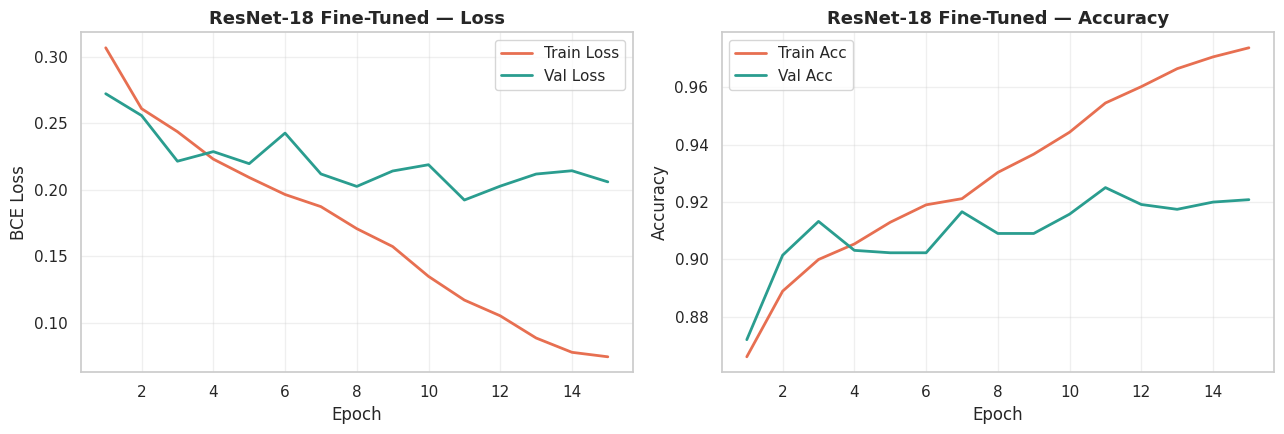

In [13]:
# 2. ResNet-18 Fine-Tuning
def build_resnet18_fine_tuned():
    base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in base.parameters():
        param.requires_grad = False
    for param in base.layer3.parameters():
        param.requires_grad = True
    for param in base.layer4.parameters():
        param.requires_grad = True
    base.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(base.fc.in_features, 1))
    return base

model_ft = build_resnet18_fine_tuned().to(DEVICE)
SAVE_FT = OUT_DIR / 'resnet18_fine_tuned.pt'

history_ft = train_model(model_ft, train_ldr_im, val_ldr_im, epochs=15, lr=3e-4, save_path=SAVE_FT, model_label="ResNet-18 Fine-Tuned")
plot_curves(history_ft, FIG_DIR / 'training_curves_resnet18_fine_tuned.png', "ResNet-18 Fine-Tuned")

model_ft.load_state_dict(torch.load(SAVE_FT, map_location=DEVICE))
metrics_ft, probs_ft, labels_ft = evaluate_model(model_ft, test_ldr_im)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


Training: EfficientNet-B0 Fine-Tuned (Epochs: 15, LR: 3.00e-04)

Epoch [01/15] | Train Loss: 0.3261, Acc: 0.8555 | Val Loss: 0.2946, Acc: 0.8593 | LR: 2.97e-04 (34.9s)
    Best model checkpoint saved (val_loss=0.2946)
Epoch [02/15] | Train Loss: 0.2652, Acc: 0.8850 | Val Loss: 0.2661, Acc: 0.8804 | LR: 2.87e-04 (34.5s)
    Best model checkpoint saved (val_loss=0.2661)
Epoch [03/15] | Train Loss: 0.2480, Acc: 0.8917 | Val Loss: 0.2515, Acc: 0.8837 | LR: 2.71e-04 (34.2s)
    Best model checkpoint saved (val_loss=0.2515)
Epoch [04/15] | Train Loss: 0.2308, Acc: 0.9035 | Val Loss: 0.2432, Acc: 0.8997 | LR: 2.50e-04 (34.7s)
    Best model checkpoint saved (val_loss=0.2432)
Epoch [05/15] | Train Loss: 0.2156, Acc: 0.9090 | Val Loss: 0.2480, Acc: 0.8896 | LR: 2.25e-04 (36.0s)
Epoch [06/15] | Train Loss: 0.2115, Acc: 0.9088 | Val Loss: 0.2431, Acc: 0.8972 | LR: 1.96e-04 (33.7s)
    Best model checkpoint saved (val_loss=0.2431)
Epoch [07/15] | Train Loss: 0.1981, Acc: 0.9159 | Val Loss: 0.2349,

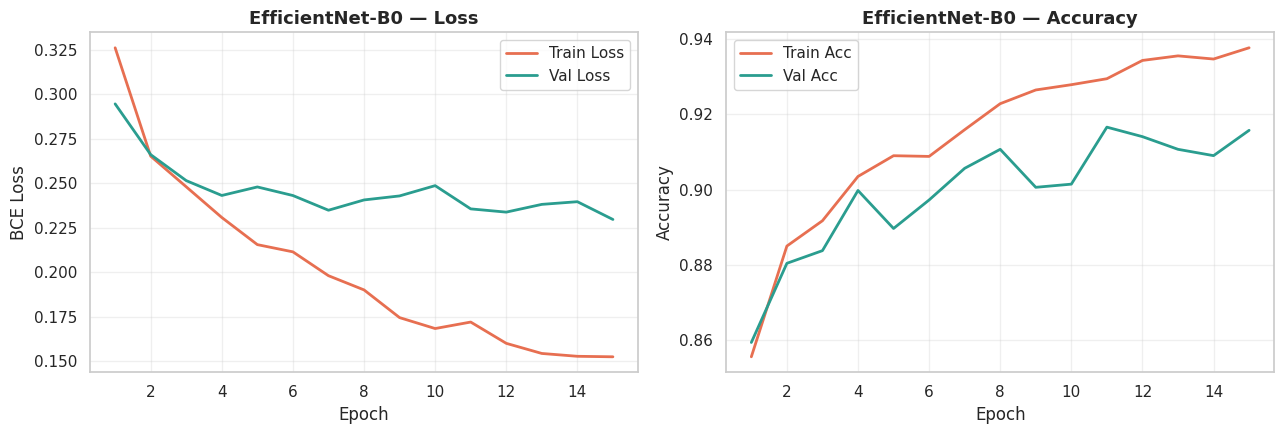

In [14]:
# 3. EfficientNet-B0 Fine-Tuning
def build_efficientnet_b0():
    base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in base.parameters():
        param.requires_grad = False
    for param in base.features[7].parameters():
        param.requires_grad = True
    for param in base.features[8].parameters():
        param.requires_grad = True
    in_features = base.classifier[1].in_features
    base.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, 1))
    return base

model_eff = build_efficientnet_b0().to(DEVICE)
SAVE_EFF = OUT_DIR / 'efficientnet_b0.pt'

history_eff = train_model(model_eff, train_ldr_im, val_ldr_im, epochs=15, lr=3e-4, save_path=SAVE_EFF, model_label="EfficientNet-B0 Fine-Tuned")
plot_curves(history_eff, FIG_DIR / 'training_curves_efficientnet_b0.png', "EfficientNet-B0")

model_eff.load_state_dict(torch.load(SAVE_EFF, map_location=DEVICE))
metrics_eff, probs_eff, labels_eff = evaluate_model(model_eff, test_ldr_im)

# Part 6: Stage 4 - Comparative Evaluation (Initial 4 Models)
Consolidate performance metrics across the 4 primary models, plotting confusion matrices, ROC curves, and Precision-Recall curves on the held-out test samples.


 FINAL MODEL COMPARISON TABLE (TEST SET EVALUATION)



,Accuracy,Precision,Sensitivity/Recall,Specificity,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,,
Baseline CNN (Scratch),0.8650,0.9011,0.8200,0.9100,0.8586,0.9461,0.9367
ResNet-18 Feature Extraction,0.8805,0.8984,0.8580,0.9030,0.8777,0.9478,0.9442
ResNet-18 Fine-Tuned,0.9405,0.9454,0.9350,0.9460,0.9402,0.9858,0.9848
EfficientNet-B0,0.9385,0.9582,0.9170,0.9600,0.9371,0.9846,0.9843


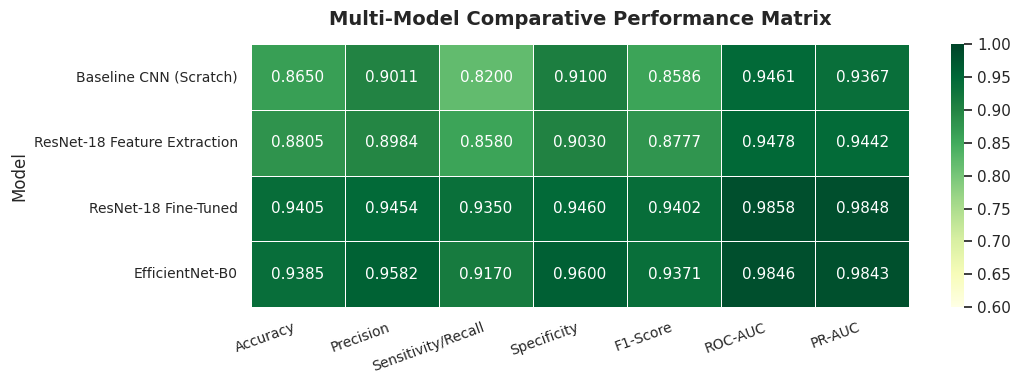

In [15]:
# Consolidated Metrics Table
models_evaluated = [
    ('Baseline CNN (Scratch)', metrics_baseline, probs_baseline, labels_baseline),
    ('ResNet-18 Feature Extraction', metrics_fe, probs_fe, labels_fe),
    ('ResNet-18 Fine-Tuned', metrics_ft, probs_ft, labels_ft),
    ('EfficientNet-B0', metrics_eff, probs_eff, labels_eff),
]

rows = []
for name, m, _, _ in models_evaluated:
    rows.append({
        'Model': name,
        'Accuracy': f"{m['accuracy']:.4f}",
        'Precision': f"{m['precision']:.4f}",
        'Sensitivity/Recall': f"{m['recall']:.4f}",
        'Specificity': f"{m['specificity']:.4f}",
        'F1-Score': f"{m['f1']:.4f}",
        'ROC-AUC': f"{m['roc_auc']:.4f}",
        'PR-AUC': f"{m['pr_auc']:.4f}",
    })

df_comparison = pd.DataFrame(rows).set_index('Model')
print(" FINAL MODEL COMPARISON TABLE (TEST SET EVALUATION)\n")
display(df_comparison)
print("\n")

# Comparison Table Heatmap
numeric_df = df_comparison.copy().astype(float)
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(numeric_df, annot=True, fmt='.4f', cmap='YlGn', linewidths=0.5, linecolor='white', ax=ax, vmin=0.6, vmax=1.0, annot_kws={'size': 11})
ax.set_title("Multi-Model Comparative Performance Matrix", fontsize=14, fontweight='bold', pad=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'comparison_table_heatmap.png', dpi=150)
plt.show()

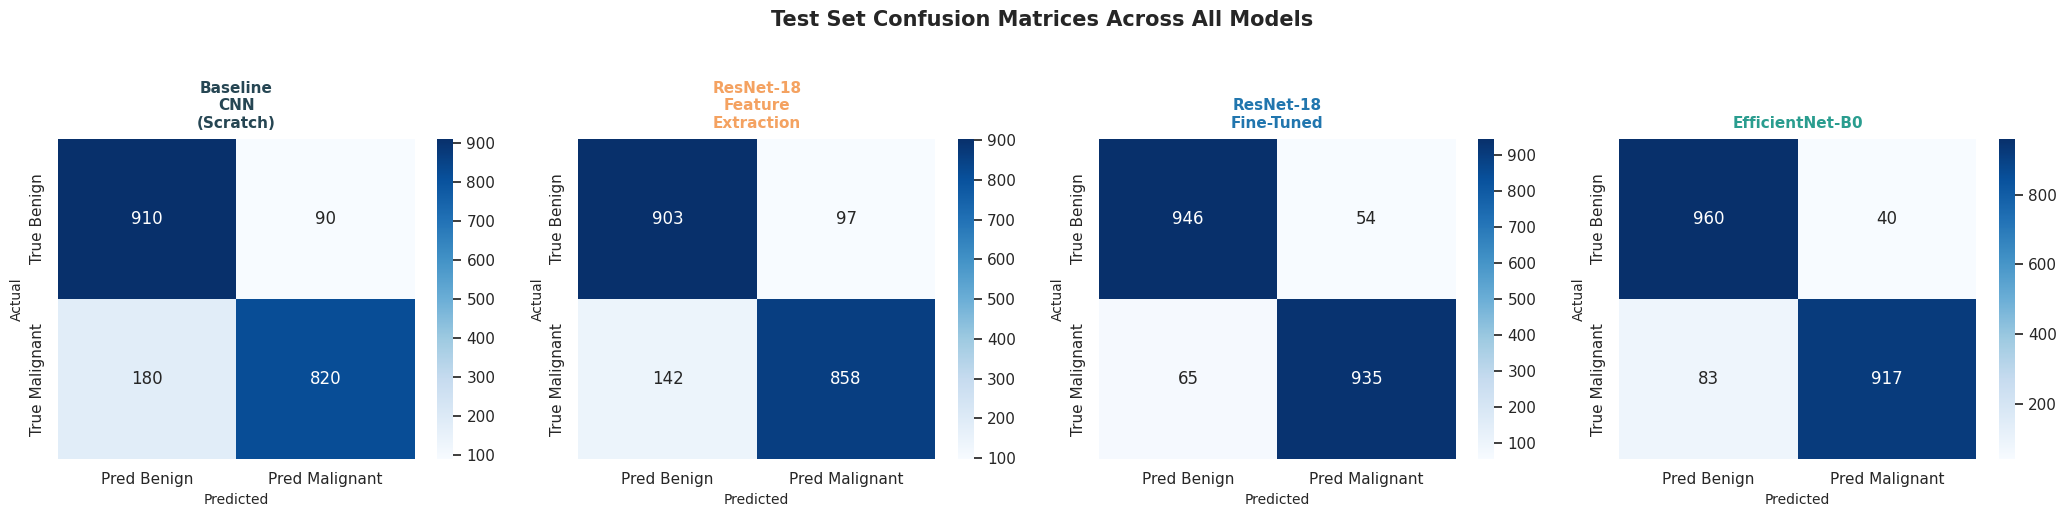

In [16]:
# Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(21, 5))
colors = ['#264653', '#F4A261', '#2176AE', '#2A9D8F']

for ax, (name, m, _, _), color in zip(axes, models_evaluated, colors):
    cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Pred Benign', 'Pred Malignant'],
        yticklabels=['True Benign', 'True Malignant'], annot_kws={'size': 12}
    )
    ax.set_title(name.replace(' ', '\n'), fontsize=11, fontweight='bold', color=color, pad=8)
    ax.set_ylabel("Actual", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)

plt.suptitle("Test Set Confusion Matrices Across All Models", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / 'side_by_side_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

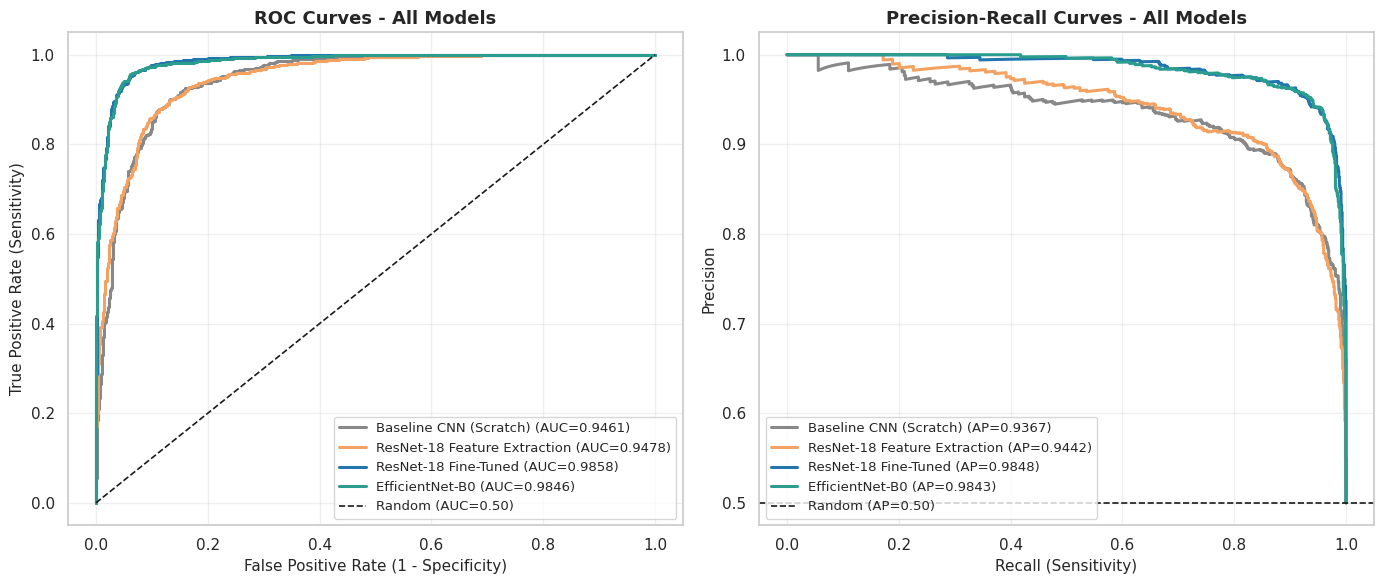

In [17]:
# ROC & Precision-Recall Curves Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
palette = {
    'Baseline CNN (Scratch)': '#888888',
    'ResNet-18 Feature Extraction': '#F4A261',
    'ResNet-18 Fine-Tuned': '#2176AE',
    'EfficientNet-B0': '#2A9D8F',
}

for name, _, probs, labels in models_evaluated:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax1.plot(fpr, tpr, lw=2.2, color=palette[name], label=f"{name} (AUC={auc:.4f})")

    prec, rec, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)
    ax2.plot(rec, prec, lw=2.2, color=palette[name], label=f"{name} (AP={ap:.4f})")

ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.50)')
ax1.set_title("ROC Curves - All Models", fontsize=13, fontweight='bold')
ax1.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax1.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
ax1.legend(loc='lower right', fontsize=9.5)
ax1.grid(alpha=0.3)

baseline_pr = labels_baseline.mean()
ax2.axhline(y=baseline_pr, color='k', linestyle='--', lw=1.2, label=f'Random (AP={baseline_pr:.2f})')
ax2.set_title("Precision-Recall Curves - All Models", fontsize=13, fontweight='bold')
ax2.set_xlabel("Recall (Sensitivity)", fontsize=11)
ax2.set_ylabel("Precision", fontsize=11)
ax2.legend(loc='lower left', fontsize=9.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'roc_and_pr_curves_comparison.png', dpi=150)
plt.show()

# Part 7: M4 Optimization - Threshold Calibration and Ensemble Blending
Implements post-processing decision threshold optimization for clinical safety (maximizing sensitivity) and soft-voting ensemble blending (0.60R + 0.40E).


  M4 THRESHOLD CALIBRATION STUDY - RESNET-18 FINE-TUNED



,Accuracy,Sensitivity (Recall),Specificity,Precision,F1-Score,False Negatives (FN),False Positives (FP)
Threshold (τ),,,,,,,
0.20,0.9380,0.9770,0.8990,0.9063,0.9403,23,101
0.25,0.9410,0.9700,0.9120,0.9168,0.9427,30,88
0.30,0.9430,0.9640,0.9220,0.9251,0.9442,36,78
0.35,0.9455,0.9600,0.9310,0.9329,0.9463,40,69
0.40,0.9450,0.9550,0.9350,0.9363,0.9455,45,65
0.45,0.9435,0.9460,0.9410,0.9413,0.9436,54,59
0.50,0.9405,0.9350,0.9460,0.9454,0.9402,65,54


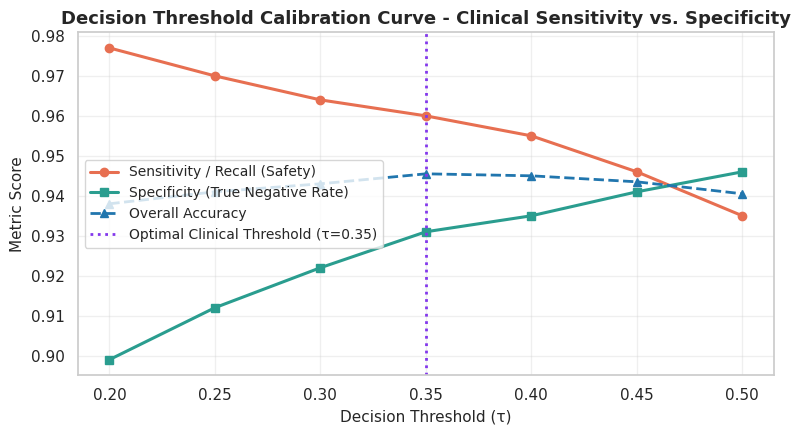

In [18]:
# Decision Threshold Calibration Study (ResNet-18 Fine-Tuned)
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
thresh_rows = []

for t in thresholds:
    preds_t = (probs_ft >= t).astype(int)
    cm_t = confusion_matrix(labels_ft, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    acc_t = accuracy_score(labels_ft, preds_t)
    prec_t = precision_score(labels_ft, preds_t, zero_division=0)
    rec_t = recall_score(labels_ft, preds_t, zero_division=0) # Sensitivity
    spec_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0.0 # Specificity
    f1_t = f1_score(labels_ft, preds_t, zero_division=0)
    
    thresh_rows.append({
        'Threshold (\u03c4)': f"{t:.2f}",
        'Accuracy': f"{acc_t:.4f}",
        'Sensitivity (Recall)': f"{rec_t:.4f}",
        'Specificity': f"{spec_t:.4f}",
        'Precision': f"{prec_t:.4f}",
        'F1-Score': f"{f1_t:.4f}",
        'False Negatives (FN)': fn_t,
        'False Positives (FP)': fp_t
    })

df_thresholds = pd.DataFrame(thresh_rows).set_index('Threshold (\u03c4)')
print("  M4 THRESHOLD CALIBRATION STUDY - RESNET-18 FINE-TUNED\n")
display(df_thresholds)

# Plot Sensitivity vs Specificity Trade-off
fig, ax = plt.subplots(figsize=(8, 4.5))
t_vals = [float(r['Threshold (\u03c4)']) for r in thresh_rows]
sens_vals = [float(r['Sensitivity (Recall)']) for r in thresh_rows]
spec_vals = [float(r['Specificity']) for r in thresh_rows]
acc_vals = [float(r['Accuracy']) for r in thresh_rows]

ax.plot(t_vals, sens_vals, marker='o', lw=2.2, color='#E76F51', label='Sensitivity / Recall (Safety)')
ax.plot(t_vals, spec_vals, marker='s', lw=2.2, color='#2A9D8F', label='Specificity (True Negative Rate)')
ax.plot(t_vals, acc_vals, marker='^', lw=2.0, color='#2176AE', linestyle='--', label='Overall Accuracy')

ax.axvline(x=0.35, color='#8338EC', linestyle=':', lw=2, label='Optimal Clinical Threshold (\u03c4=0.35)')
ax.set_title("Decision Threshold Calibration Curve - Clinical Sensitivity vs. Specificity", fontsize=13, fontweight='bold')
ax.set_xlabel("Decision Threshold (\u03c4)", fontsize=11)
ax.set_ylabel("Metric Score", fontsize=11)
ax.legend(fontsize=10, loc='center left')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'threshold_calibration_curve.png', dpi=150)
plt.show()

In [19]:
# Ensemble Model Blending (ResNet-18 FT + EfficientNet-B0)
# Soft probability blending (60% ResNet-18 + 40% EfficientNet-B0)
probs_ensemble = (0.60 * probs_ft) + (0.40 * probs_eff)
labels_ensemble = labels_ft  # Ground truth labels are identical

# Evaluate Ensemble at standard threshold (0.50) and calibrated threshold (0.35)
def evaluate_custom_probs(probs, labels, threshold=0.50, model_name="Ensemble"):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'Model': f"{model_name} (\u03c4={threshold:.2f})",
        'Accuracy': float(accuracy_score(labels, preds)),
        'Precision': float(precision_score(labels, preds, zero_division=0)),
        'Sensitivity/Recall': float(recall_score(labels, preds, zero_division=0)),
        'Specificity': float(spec),
        'F1-Score': float(f1_score(labels, preds, zero_division=0)),
        'ROC-AUC': float(roc_auc_score(labels, probs)),
        'PR-AUC': float(average_precision_score(labels, probs)),
        'FN': int(fn),
        'FP': int(fp),
        'TP': int(tp),
        'TN': int(tn)
    }, preds

metrics_ens_std, preds_ens_std = evaluate_custom_probs(probs_ensemble, labels_ensemble, threshold=0.50, model_name="Ensemble (ResNet18 + EffNet)")
metrics_ens_cal, preds_ens_cal = evaluate_custom_probs(probs_ensemble, labels_ensemble, threshold=0.35, model_name="Ensemble (ResNet18 + EffNet)")

print("Ensemble evaluation complete")
print(f"    Ensemble (t=0.50) -> Accuracy: {metrics_ens_std['Accuracy']:.4f}, Sensitivity: {metrics_ens_std['Sensitivity/Recall']:.4f}, ROC-AUC: {metrics_ens_std['ROC-AUC']:.4f}")
print(f"    Ensemble (t=0.35) -> Accuracy: {metrics_ens_cal['Accuracy']:.4f}, Sensitivity: {metrics_ens_cal['Sensitivity/Recall']:.4f}, FN: {metrics_ens_cal['FN']}")

Ensemble evaluation complete
    Ensemble (t=0.50) -> Accuracy: 0.9520, Sensitivity: 0.9430, ROC-AUC: 0.9903
    Ensemble (t=0.35) -> Accuracy: 0.9505, Sensitivity: 0.9720, FN: 28


In [20]:
# M4 Step 3: Complete Final M4 Ablation Table (All Models & Thresholds)
# Also evaluate ResNet-18 FT at calibrated threshold 0.35
metrics_ft_cal, _ = evaluate_custom_probs(probs_ft, labels_ft, threshold=0.35, model_name="ResNet-18 Fine-Tuned")

final_m4_models = [
    ('Baseline CNN (Scratch)', metrics_baseline),
    ('ResNet-18 Feature Extraction (\u03c4=0.50)', metrics_fe),
    ('EfficientNet-B0 (\u03c4=0.50)', metrics_eff),
    ('ResNet-18 Fine-Tuned (\u03c4=0.50)', metrics_ft),
    ('ResNet-18 Fine-Tuned (\u03c4=0.35) [Calibrated]', metrics_ft_cal),
    ('Ensemble [ResNet18+EffNet] (\u03c4=0.50)', metrics_ens_std),
    ('Ensemble [ResNet18+EffNet] (\u03c4=0.35) [Best Safety]', metrics_ens_cal),
]

m4_rows = []
for name, m in final_m4_models:
    m4_rows.append({
        'Experiment Configuration': name,
        'Accuracy': f"{m['Accuracy'] if 'Accuracy' in m else m['accuracy']:.4f}",
        'Sensitivity (Recall)': f"{m['Sensitivity/Recall'] if 'Sensitivity/Recall' in m else m['recall']:.4f}",
        'Specificity': f"{m['Specificity'] if 'Specificity' in m else m['specificity']:.4f}",
        'Precision': f"{m['Precision'] if 'Precision' in m else m['precision']:.4f}",
        'F1-Score': f"{m['F1-Score'] if 'F1-Score' in m else m['f1']:.4f}",
        'ROC-AUC': f"{m['ROC-AUC'] if 'ROC-AUC' in m else m['roc_auc']:.4f}",
        'Missed Melanomas (FN)': m['FN'] if 'FN' in m else m['fn']
    })

df_m4_final = pd.DataFrame(m4_rows).set_index('Experiment Configuration')
print(" FINAL M4 FROZEN EXPERIMENTAL ABLATION TABLE (TEST SET)\n")
display(df_m4_final)

# Save updated metrics JSON for M4 freeze
m4_json_dict = {
    'baseline_cnn': metrics_baseline,
    'resnet18_feat_ext': metrics_fe,
    'efficientnet_b0': metrics_eff,
    'resnet18_fine_tuned_t050': metrics_ft,
    'resnet18_fine_tuned_t035': metrics_ft_cal,
    'ensemble_t050': metrics_ens_std,
    'ensemble_t035': metrics_ens_cal,
}
with open(OUT_DIR / 'm4_frozen_metrics.json', 'w') as f:
    json.dump(m4_json_dict, f, indent=2)

print(f"M4 Experiment Freeze Complete. Saved to {OUT_DIR / 'm4_frozen_metrics.json'}")

 FINAL M4 FROZEN EXPERIMENTAL ABLATION TABLE (TEST SET)



,Accuracy,Sensitivity (Recall),Specificity,Precision,F1-Score,ROC-AUC,Missed Melanomas (FN)
Experiment Configuration,,,,,,,
Baseline CNN (Scratch),0.8650,0.8200,0.9100,0.9011,0.8586,0.9461,180
ResNet-18 Feature Extraction (τ=0.50),0.8805,0.8580,0.9030,0.8984,0.8777,0.9478,142
EfficientNet-B0 (τ=0.50),0.9385,0.9170,0.9600,0.9582,0.9371,0.9846,83
ResNet-18 Fine-Tuned (τ=0.50),0.9405,0.9350,0.9460,0.9454,0.9402,0.9858,65
ResNet-18 Fine-Tuned (τ=0.35) [Calibrated],0.9455,0.9600,0.9310,0.9329,0.9463,0.9858,40
Ensemble [ResNet18+EffNet] (τ=0.50),0.9520,0.9430,0.9610,0.9603,0.9516,0.9903,57
Ensemble [ResNet18+EffNet] (τ=0.35) [Best Safety],0.9505,0.9720,0.9290,0.9319,0.9515,0.9903,28


M4 Experiment Freeze Complete. Saved to /kaggle/working/m4_frozen_metrics.json


# Part 8: Stage 5 - Diagnostic Misclassification Analysis
Identifie and visually inspect False Positives (over-diagnosis) and False Negatives (missed melanomas / clinical risk) to evaluate model failure modes.


In [21]:
# Select Best Model
# best_name, best_m, best_probs, best_labels = max(models_evaluated, key=lambda x: x[1]['roc_auc'])
best_name, best_m, best_probs, best_labels = [m for m in models_evaluated if m[0] == 'ResNet-18 Fine-Tuned'][0]
print(f"Best Performing Model: {best_name} (ROC-AUC: {best_m['roc_auc']:.4f}, Accuracy: {best_m['accuracy']:.4f})")

test_paths = [s[0] for s in test_ldr_im.dataset.samples]
best_preds = (best_probs >= 0.5).astype(int)

fp_indices = np.where((best_preds == 1) & (best_labels == 0))[0]
fn_indices = np.where((best_preds == 0) & (best_labels == 1))[0]

print(f"  False Positives (Benign misclassified as Malignant): {len(fp_indices)}")
print(f"  False Negatives (Malignant missed as Benign) : {len(fn_indices)} [CRITICAL CLINICAL RISK]")

Best Performing Model: ResNet-18 Fine-Tuned (ROC-AUC: 0.9858, Accuracy: 0.9405)
  False Positives (Benign misclassified as Malignant): 54
  False Negatives (Malignant missed as Benign) : 65 [CRITICAL CLINICAL RISK]


[Saved] misclassified_false_positives.png


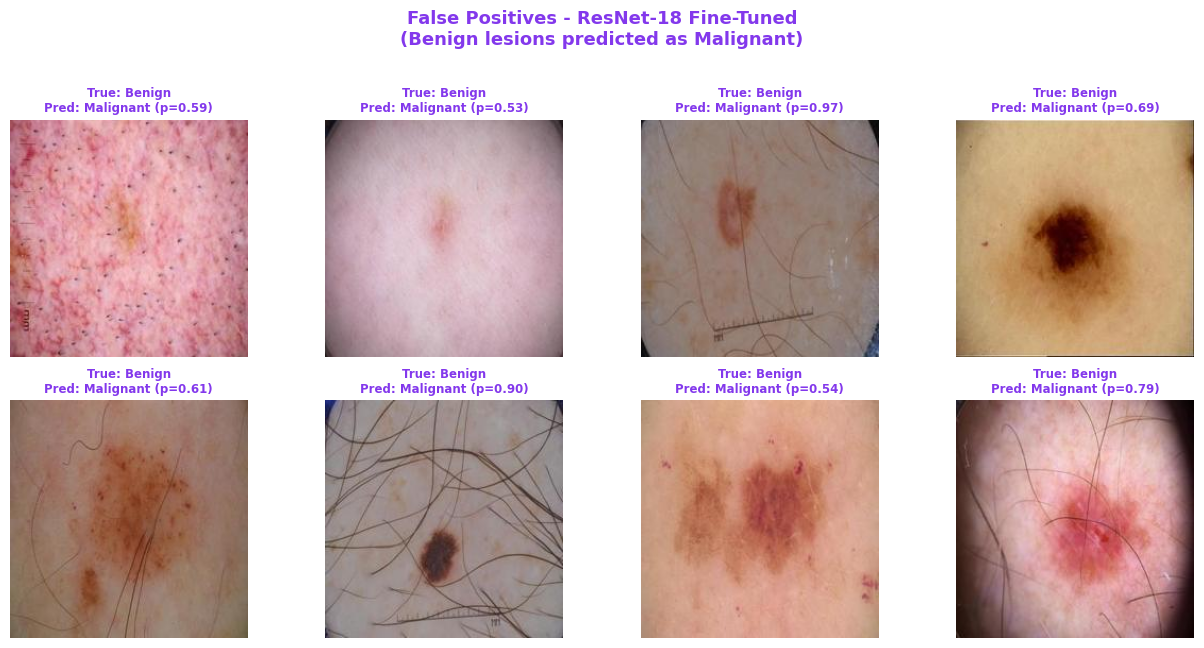

[Saved] misclassified_false_negatives.png


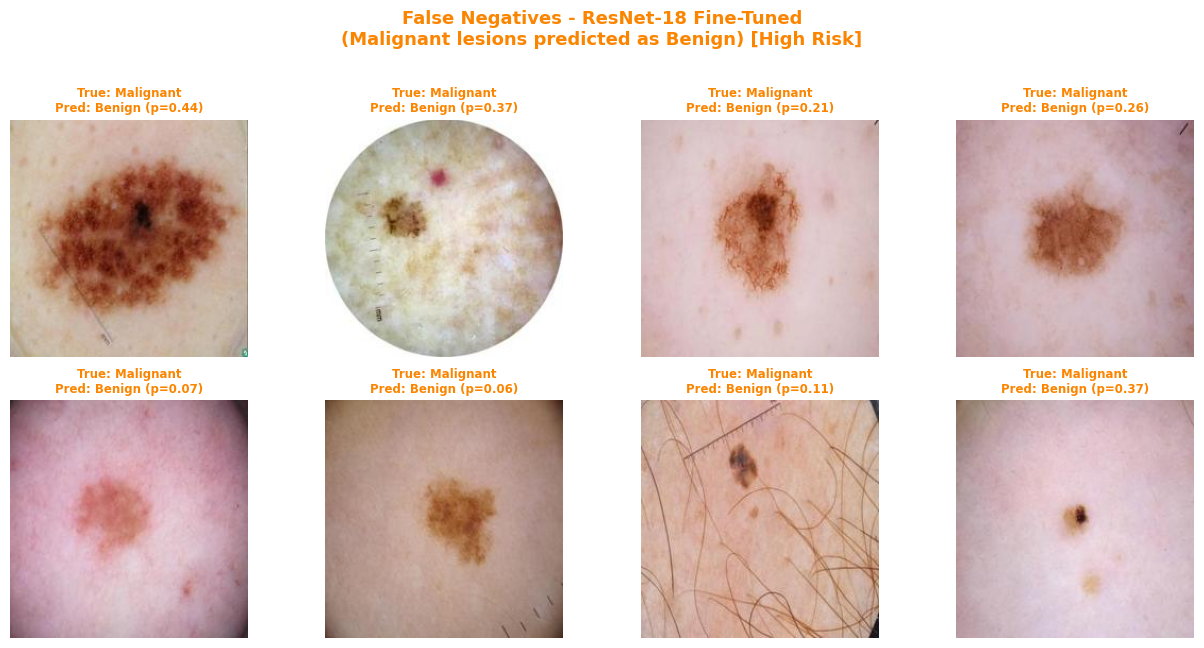

In [22]:
# Diagnostic Misclassification Grids (False Positives & False Negatives)
def display_error_grid(indices, title, header_color, is_fp=True, n_show=8, save_path=None):
    if len(indices) == 0:
        print(f"No error samples for {title}")
        return
    
    rng = np.random.default_rng(SEED)
    selected = rng.choice(indices, size=min(n_show, len(indices)), replace=False)
    n_cols = 4
    n_rows = (len(selected) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 3.2))
    axes = np.array(axes).reshape(-1)

    for ax_idx, img_idx in enumerate(selected):
        ax = axes[ax_idx]
        img = Image.open(test_paths[img_idx]).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        
        p = best_probs[img_idx]
        true_str = "Benign" if best_labels[img_idx] == 0 else "Malignant"
        pred_str = "Malignant" if is_fp else "Benign"
        
        ax.set_title(f"True: {true_str}\nPred: {pred_str} (p={p:.2f})", fontsize=8.5, color=header_color, fontweight='bold')

    for ax in axes[len(selected):]:
        ax.axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold', color=header_color, y=1.01)
    plt.tight_layout()
    
    # Save image to figures directory if path provided
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[Saved] {save_path.name}")
        
    plt.show()

# False Positives (Benign misclassified as Malignant - Over-diagnosis)
display_error_grid(
    fp_indices,
    title=f"False Positives - {best_name}\n(Benign lesions predicted as Malignant)",
    header_color='#8338EC',
    is_fp=True,
    n_show=8,
    save_path=FIG_DIR / 'misclassified_false_positives.png'
)

# False Negatives (Malignant misclassified as Benign - Critical Clinical Risk)
display_error_grid(
    fn_indices,
    title=f"False Negatives - {best_name}\n(Malignant lesions predicted as Benign) [High Risk]",
    header_color='#FB8500',
    is_fp=False,
    n_show=8,
    save_path=FIG_DIR / 'misclassified_false_negatives.png'
)

# Part 9: Stage 6 - Explainable AI via Grad-CAM Saliency Mapping
Implement hook-based Grad-CAM to visualize spatial gradient activations across 4 clinical diagnostic groups and compare Baseline CNN vs. ResNet-18 attention localization.


In [23]:
class GradCAM:
    """Hook-based Grad-CAM implementation for PyTorch CNNs."""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.fmaps = None
        self.grads = None
        self.fwd_hook = target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'fmaps', o.detach()))
        self.bwd_hook = target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, x):
        self.model.zero_grad()
        logit = self.model(x).squeeze()
        logit.backward()

        alpha = self.grads.squeeze(0).mean(dim=(-2, -1))
        cam   = (alpha[:, None, None] * self.fmaps.squeeze(0)).sum(0)
        cam   = torch.relu(cam).cpu().numpy()

        h, w = x.shape[-2], x.shape[-1]
        cam  = cv2.resize(cam, (w, h))
        mn, mx = cam.min(), cam.max()
        return ((cam - mn) / (mx - mn + 1e-8)).astype(np.float32)

    def remove(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

def denormalize_img(tensor, mean, std):
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    arr = (tensor.cpu() * s + m).permute(1, 2, 0).numpy()
    return (np.clip(arr, 0, 1) * 255).astype(np.uint8)

def create_gradcam_overlay(img_rgb, heatmap, alpha=0.45):
    hm_uint8 = (heatmap * 255).astype(np.uint8)
    hm_color = cv2.applyColorMap(hm_uint8, cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    return (alpha * hm_color + (1 - alpha) * img_rgb).astype(np.uint8)

print("Grad-CAM engine initialized.")

Grad-CAM engine initialized.


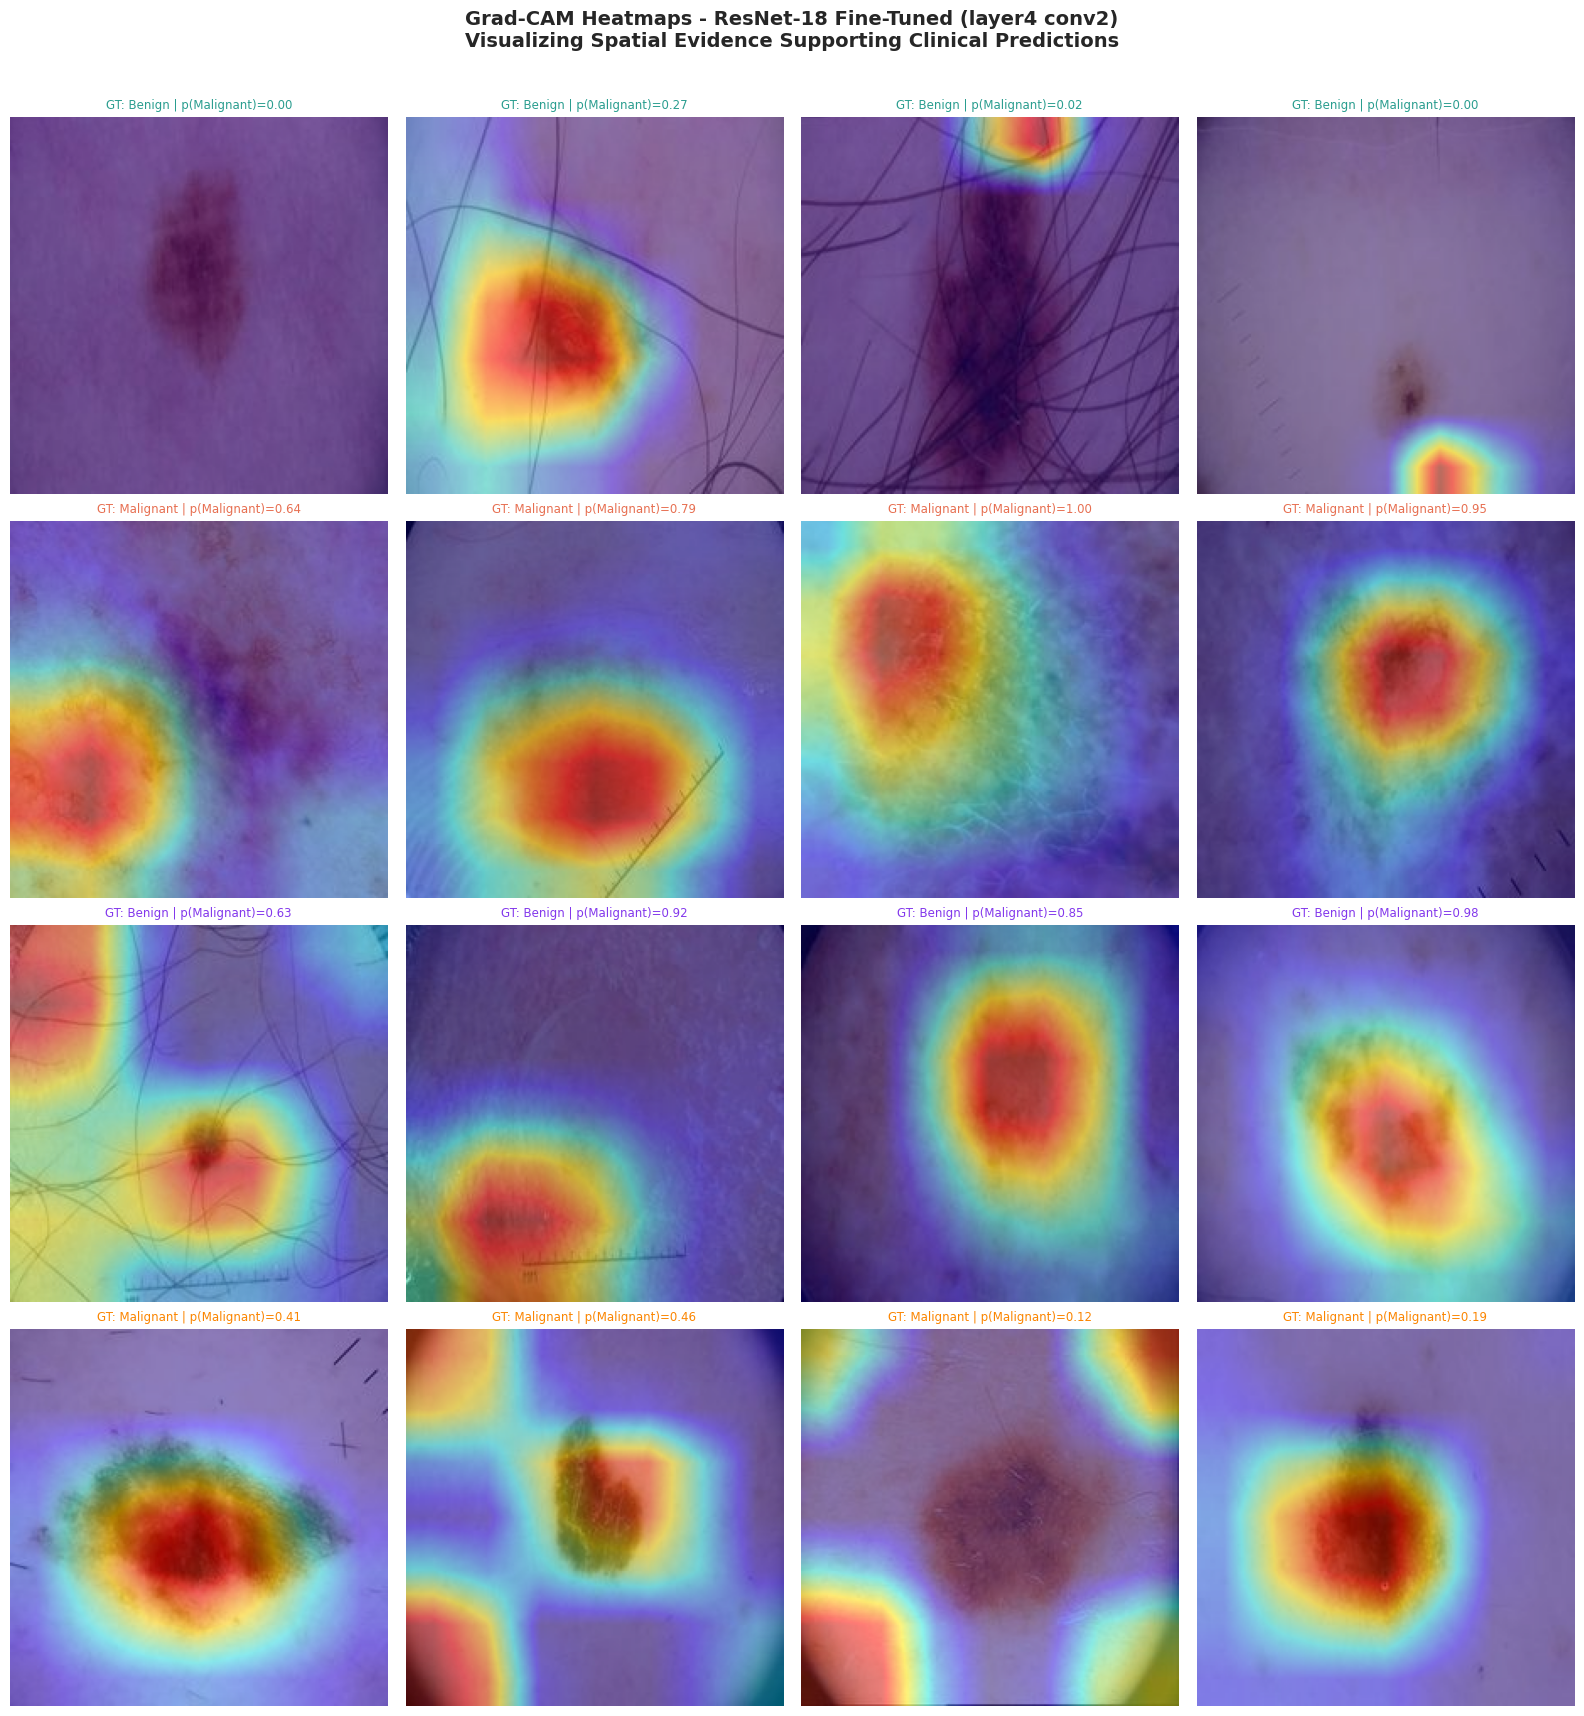

In [24]:
# 1. ResNet-18 Grad-CAM Grid Across 4 Clinical Groups
target_layer_resnet = model_ft.layer4[-1].conv2
gcam_resnet = GradCAM(model_ft, target_layer_resnet)

rng = np.random.default_rng(SEED)
def sample_idx(mask, n=4):
    idx = np.where(mask)[0]
    return rng.choice(idx, size=min(n, len(idx)), replace=False)

# Use ResNet-18's OWN predictions here - not whichever model happened to
# win best ROC-AUC in Part 7 - so the group labels and probabilities match
# the model whose CAM is actually being rendered.
preds_ft = (probs_ft >= 0.5).astype(int)

idx_cb = sample_idx((preds_ft == 0) & (labels_ft == 0), 4) # Correct Benign
idx_cm = sample_idx((preds_ft == 1) & (labels_ft == 1), 4) # Correct Malignant
idx_fp = sample_idx((preds_ft == 1) & (labels_ft == 0), 4) # False Positive
idx_fn = sample_idx((preds_ft == 0) & (labels_ft == 1), 4) # False Negative

cam_groups = [
    ('Correct Benign', idx_cb, '#2A9D8F'),
    ('Correct Malignant', idx_cm, '#E76F51'),
    ('False Positive', idx_fp, '#8338EC'),
    ('False Negative', idx_fn, '#FB8500'),
]

fig = plt.figure(figsize=(16, 17))
fig.suptitle("Grad-CAM Heatmaps - ResNet-18 Fine-Tuned (layer4 conv2)\nVisualizing Spatial Evidence Supporting Clinical Predictions", fontsize=14, fontweight='bold', y=1.01)

for row, (group_name, indices, color) in enumerate(cam_groups):
    for col, img_idx in enumerate(indices):
        ax = fig.add_subplot(4, 4, row * 4 + col + 1)
        img_tensor, true_lbl = test_ldr_im.dataset[img_idx]
        hmap = gcam_resnet(img_tensor.unsqueeze(0).to(DEVICE))
        rgb  = denormalize_img(img_tensor, IMAGENET_MEAN, IMAGENET_STD)
        overlay = create_gradcam_overlay(rgb, hmap)

        ax.imshow(overlay)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(group_name, color=color, fontsize=11, fontweight='bold', labelpad=8)
        prob = probs_ft[img_idx] # ResNet-18's own probability, not best_probs
        gt_str = CLASS_NAMES[true_lbl].capitalize()
        ax.set_title(f"GT: {gt_str} | p(Malignant)={prob:.2f}", fontsize=8.5, color=color)

plt.tight_layout()
fig.savefig(FIG_DIR / 'gradcam_resnet18_fine_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
gcam_resnet.remove()

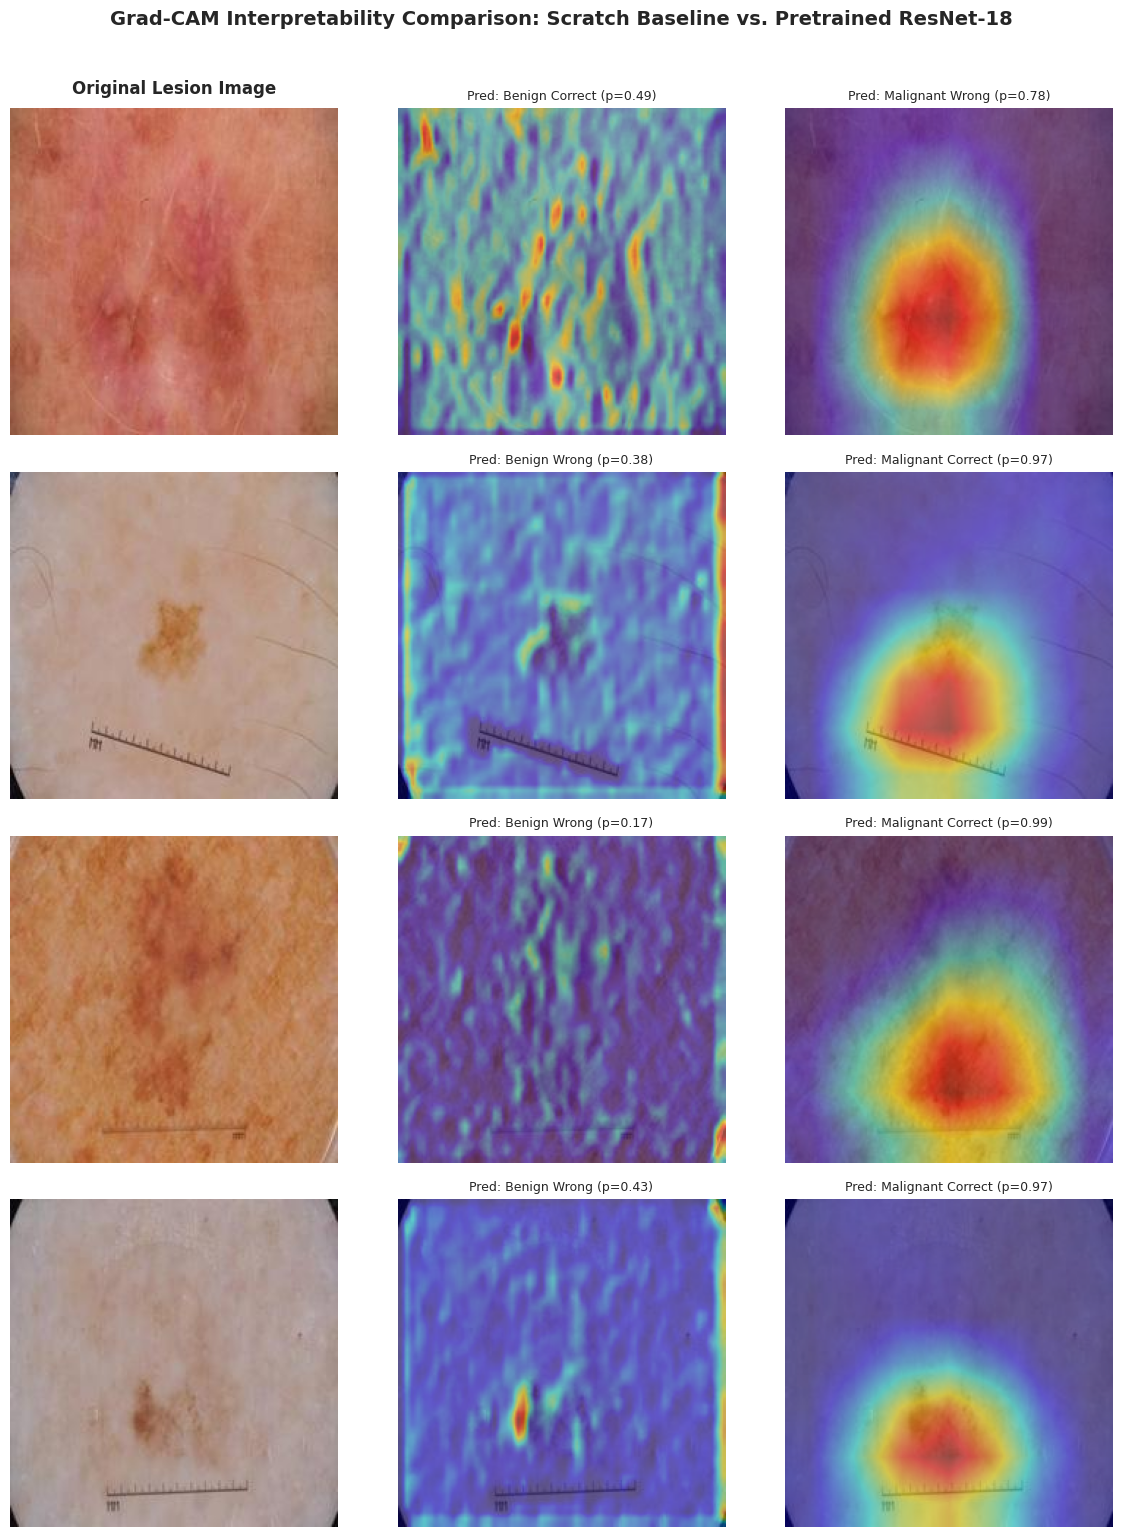

In [25]:
# 2. Side-by-Side Model Comparison: Baseline CNN vs ResNet-18
target_layer_cnn = model_baseline.features[-1].block[0]
gcam_cnn = GradCAM(model_baseline, target_layer_cnn)
gcam_r = GradCAM(model_ft, model_ft.layer4[-1].conv2)

# Find cases where Baseline CNN and ResNet-18 SPECIFICALLY disagree
# (not "baseline vs whichever model won ROC-AUC" - that could silently
# become a baseline-vs-EfficientNet comparison mislabeled as ResNet-18)
preds_b = (probs_baseline >= 0.5).astype(int)
preds_ft = (probs_ft >= 0.5).astype(int)
disagree = np.where(preds_b != preds_ft)[0]
if len(disagree) >= 4:
    compare_indices = rng.choice(disagree, size=4, replace=False)
else:
    compare_indices = rng.choice(range(len(labels_ft)), size=4, replace=False)

fig, axes = plt.subplots(len(compare_indices), 3, figsize=(12, len(compare_indices) * 3.8))
col_titles = ['Original Lesion Image', 'Baseline CNN (Scratch) CAM', 'ResNet-18 Fine-Tuned CAM']
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontsize=12, fontweight='bold', pad=10)

for row, img_idx in enumerate(compare_indices):
    # Original
    orig_p = test_paths[img_idx]
    orig_img = Image.open(orig_p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[row, 0].imshow(orig_img)
    axes[row, 0].axis('off')
    gt_str = CLASS_NAMES[labels_ft[img_idx]].capitalize()
    axes[row, 0].set_ylabel(f"GT: {gt_str}", fontsize=11, fontweight='bold', labelpad=8)

    # Baseline CAM
    img_b_tensor, _ = test_ldr_ds.dataset[img_idx]
    hmap_b = gcam_cnn(img_b_tensor.unsqueeze(0).to(DEVICE))
    rgb_b  = denormalize_img(img_b_tensor, DATASET_MEAN, DATASET_STD)
    axes[row, 1].imshow(create_gradcam_overlay(rgb_b, hmap_b))
    axes[row, 1].axis('off')
    p_b = probs_baseline[img_idx]
    pred_b_str = CLASS_NAMES[int(p_b >= 0.5)].capitalize()
    mark_b = "Correct" if (p_b >= 0.5) == labels_ft[img_idx] else "Wrong"
    axes[row, 1].set_title(f"Pred: {pred_b_str} {mark_b} (p={p_b:.2f})", fontsize=9)

    # ResNet-18 CAM
    img_r_tensor, _ = test_ldr_im.dataset[img_idx]
    hmap_r = gcam_r(img_r_tensor.unsqueeze(0).to(DEVICE))
    rgb_r  = denormalize_img(img_r_tensor, IMAGENET_MEAN, IMAGENET_STD)
    axes[row, 2].imshow(create_gradcam_overlay(rgb_r, hmap_r))
    axes[row, 2].axis('off')
    p_r = probs_ft[img_idx]          # ResNet-18's own probability, not best_probs
    pred_r_str = CLASS_NAMES[int(p_r >= 0.5)].capitalize()
    mark_r = "Correct" if (p_r >= 0.5) == labels_ft[img_idx] else "Wrong"
    axes[row, 2].set_title(f"Pred: {pred_r_str} {mark_r} (p={p_r:.2f})", fontsize=9)

plt.suptitle("Grad-CAM Interpretability Comparison: Scratch Baseline vs. Pretrained ResNet-18",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'gradcam_baseline_vs_resnet18_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

gcam_cnn.remove()
gcam_r.remove()

# Part 10: Summary and Export Final Metrics JSON
Export structured evaluation metrics to `metrics.json` and archive all generated figures and model weights.


In [26]:
# Save metrics.json for programmatic verification
final_metrics_dict = {
    'baseline_cnn': metrics_baseline,
    'resnet18_feature_extraction': metrics_fe,
    'resnet18_fine_tuned': metrics_ft,
    'efficientnet_b0': metrics_eff,
}

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(final_metrics_dict, f, indent=2)

print(f"Master Execution Completed Successfully")
print(f"Metrics JSON exported to: {OUT_DIR / 'metrics.json'}")
print(f"All figures generated in: {FIG_DIR}\n")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"    {p.relative_to(OUT_DIR)}")

Master Execution Completed Successfully
Metrics JSON exported to: /kaggle/working/metrics.json
All figures generated in: /kaggle/working/figures

    .virtual_documents/__notebook_source__.ipynb
    baseline_cnn.pt
    efficientnet_b0.pt
    figures/comparison_table_heatmap.png
    figures/dataset_class_distribution.png
    figures/gradcam_baseline_vs_resnet18_comparison.png
    figures/gradcam_resnet18_fine_tuned.png
    figures/misclassified_false_negatives.png
    figures/misclassified_false_positives.png
    figures/roc_and_pr_curves_comparison.png
    figures/sample_images_inspection.png
    figures/side_by_side_confusion_matrices.png
    figures/threshold_calibration_curve.png
    figures/training_curves_baseline.png
    figures/training_curves_efficientnet_b0.png
    figures/training_curves_resnet18_feat_ext.png
    figures/training_curves_resnet18_fine_tuned.png
    m4_frozen_metrics.json
    metrics.json
    resnet18_feature_extraction.pt
    resnet18_fine_tuned.pt
